# Scenario 01 - Long-Document Chat (Any `docs/*.md`)
This scenario sends *many* questions against one long document by embedding the document into a shared `system` prompt.
Pick a document by setting `DOC` (or `SCENARIO_DOC`) to a filename in `docs/`.
The goal is to observe serving behavior when the **long prefix is identical across requests** (often improved TTFT on follow-ups).

In [1]:
from pathlib import Path
import os
import time
import uuid
from statistics import median
from typing import Any
import matplotlib.pyplot as plt
from openai import OpenAI


def load_dotenv(path: Path) -> None:
    if not path.is_file():
        return
    for raw_line in path.read_text(encoding='utf-8').splitlines():
        line = raw_line.strip()
        if not line or line.startswith('#'):
            continue
        if '=' not in line:
            continue
        key, value = (part.strip() for part in line.split('=', 1))
        if not key or key in os.environ:
            continue
        if (value.startswith('"')
                and value.endswith('"')) or (value.startswith("'")
                                             and value.endswith("'")):
            value = value[1:-1]
        os.environ[key] = value


load_dotenv(Path('.env'))
load_dotenv(Path('../../.env'))

### Document

In [2]:
DOCS_DIR = Path(os.environ.get('DOCS_DIR', 'docs'))
if not DOCS_DIR.is_dir():
    raise FileNotFoundError(f"Docs directory not found: {DOCS_DIR}")

AVAILABLE_DOCS = sorted(DOCS_DIR.glob('*.md'))
if not AVAILABLE_DOCS:
    raise FileNotFoundError(f"No .md files found under: {DOCS_DIR}")

doc_name = (os.environ.get('DOC') or os.environ.get('SCENARIO_DOC')
            or 'cancer_disease.md').strip()
if doc_name and not doc_name.endswith('.md') and '/' not in doc_name:
    doc_name = f"{doc_name}.md"

DOCUMENT_PATH = Path(doc_name)
if not DOCUMENT_PATH.is_file():
    DOCUMENT_PATH = DOCS_DIR / doc_name
if not DOCUMENT_PATH.is_file():
    raise FileNotFoundError(f"DOC={doc_name!r} not found. Available: " +
                            ", ".join(path.name for path in AVAILABLE_DOCS))

DOCUMENT = DOCUMENT_PATH.read_text(encoding='utf-8').strip()
print(f"Loaded document: {DOCUMENT_PATH} ({len(DOCUMENT):,} chars)")
print("Available docs:")
for path in AVAILABLE_DOCS:
    marker = "*" if path.name == DOCUMENT_PATH.name else " "
    print(f"  {marker} {path.name}")

Loaded document: docs/cancer_disease.md (40,446 chars)
Available docs:
  * cancer_disease.md
    k8s.md


### Questions

In [3]:
QUESTIONS = [
    "What is the main topic of this document?",
    "Summarize the document in 3–5 sentences.",
    "Who is the intended audience of this document?",
    "What problem is this document trying to solve?",
    "What are the main sections or chapters in this document?",
    "Which section contains the most important information? Why?",
    "List the key topics discussed in the document.",
    "What are the most important facts mentioned in the document?",
    "Extract all definitions or key terms mentioned.",
    "What are the key arguments or claims made by the author?",
    "Find a paragraph that explains the core concept.",
    "Quote the part where the document explains the main idea.",
    "What examples are used to explain the topic?",
    "What conclusions can be drawn from the document?",
    "What assumptions does the author make?",
    "What are potential limitations or weaknesses in the document?",
    "How do different sections of the document relate to each other?",
    "What earlier information is required to understand the later parts?",
    "How could the information in this document be applied in practice?",
    "If you had to teach this document to someone else, what would you explain first?",
]

print(f"Questions: default ({len(QUESTIONS)})")

Questions: default (20)


### Implementation

## Setup And Run

Required environment variables:
- `OPENAI_BASE_URL`
- `OPENAI_API_KEY`
- `TENSORMESH_USER_ID`
- `OPENAI_MODEL`

Optional:
- `DOC` or `SCENARIO_DOC` (a filename under `scenarios/01_long_document_chat/docs/`, e.g. `k8s.md`)
- `DOCS_DIR` (override docs directory path)

In [4]:
def require_env(name: str) -> str:
    value = (os.environ.get(name) or '').strip()
    if not value:
        raise EnvironmentError(f"Missing required env var: {name}")
    return value


base_url = require_env('OPENAI_BASE_URL')
api_key = require_env('OPENAI_API_KEY')
user_id = require_env('TENSORMESH_USER_ID')
model = require_env('OPENAI_MODEL')

session_hash = uuid.uuid4().hex[:12]
shared_system_prompt = '\n\n'.join([
    f'DEMO_SESSION_HASH={session_hash}',
    'ROLE: Answer questions using only the reference document below.',
    'RULE: Use only the reference content below. If the reference does not support a claim, say "not stated in reference".',
    'STYLE: Respond in concise bullets.',
    f'REFERENCE_DOCUMENT: {DOCUMENT_PATH.name}',
    DOCUMENT,
])

print('Configuration')
print(f'  OPENAI_BASE_URL      : {base_url}')
print(f'  OPENAI_MODEL         : {model}')
print(f'  TENSORMESH_USER_ID   : {user_id}')
print(f"  OPENAI_API_KEY       : {'(set)' if api_key else '(missing)'}")
print(f'  document_characters  : {len(DOCUMENT):,}')
print(f'  session_hash         : {session_hash}')
print(f'  questions            : {len(QUESTIONS)}')

Configuration
  OPENAI_BASE_URL      : https://external.nebius.tensormesh.ai/v1
  OPENAI_MODEL         : openai-gpt-oss-20b-gpu-type-h200x1_efvggz
  TENSORMESH_USER_ID   : 60b01a41-c8a4-4234-80a5-ef18309b560c
  OPENAI_API_KEY       : (set)
  document_characters  : 40,446
  session_hash         : 74c70e411752
  questions            : 20


In [5]:
client = OpenAI(
    api_key=api_key,
    base_url=base_url,
    default_headers={'X-User-Id': user_id},
)


def run_document_question(question_label: str,
                          question_text: str) -> dict[str, Any]:
    started_at = time.perf_counter()
    first_token_ms: float | None = None
    content_parts: list[str] = []
    reasoning_parts: list[str] = []
    last_usage = None

    stream = client.chat.completions.create(
        model=model,
        messages=[
            {
                'role': 'system',
                'content': shared_system_prompt
            },
            {
                'role': 'user',
                'content': question_text
            },
        ],
        stream=True,
        stream_options={'include_usage': True},
    )

    for chunk in stream:
        if getattr(chunk, 'usage', None):
            last_usage = chunk.usage
        if not getattr(chunk, 'choices', None):
            continue
        delta = chunk.choices[0].delta
        content = getattr(delta, 'content', None) or ''
        reasoning = getattr(delta, 'reasoning', None) or ''
        if content:
            content_parts.append(content)
        if reasoning:
            reasoning_parts.append(reasoning)
        if first_token_ms is None and (content or reasoning):
            first_token_ms = (time.perf_counter() - started_at) * 1000

    finished_at = time.perf_counter()
    e2e_ms = (finished_at - started_at) * 1000
    if first_token_ms is None:
        raise RuntimeError('No text tokens were emitted by the stream.')

    completion_tokens = getattr(last_usage, 'completion_tokens', None)
    prompt_tokens = getattr(last_usage, 'prompt_tokens', None)
    total_tokens = getattr(last_usage, 'total_tokens', None)

    itl_ms = None
    if isinstance(completion_tokens, int) and completion_tokens > 1:
        itl_ms = (e2e_ms - first_token_ms) / (completion_tokens - 1)

    answer_text = ''.join(content_parts or reasoning_parts).strip()
    return {
        'run_label': question_label,
        'question': question_text,
        'answer': answer_text,
        'answer_characters': len(answer_text),
        'ttft_ms': first_token_ms,
        'e2e_ms': e2e_ms,
        'itl_ms': itl_ms,
        'prompt_tokens': prompt_tokens,
        'completion_tokens': completion_tokens,
        'total_tokens': total_tokens,
    }

In [6]:
records: list[dict[str, Any]] = []

print('Running one chat session over a shared long-prefix document')
for question_id, question_text in enumerate(QUESTIONS):
    question_label = f'Q{question_id + 1}'
    result = run_document_question(question_label, question_text)
    records.append(result)

    print(f"\n--- {question_label} ---")
    print(f"Q: {result['question']}")
    print('A:')
    print(result['answer'])
    itl_display = 'n/a' if result[
        'itl_ms'] is None else f"{result['itl_ms']:.1f} ms/token"
    out_tokens = result.get('completion_tokens')
    out_tokens_display = 'n/a' if out_tokens is None else str(out_tokens)
    print(
        f"Metrics: TTFT={result['ttft_ms']:.1f} ms  E2E={result['e2e_ms']:.1f} ms  ITL={itl_display}  out_tokens={out_tokens_display}"
    )

Running one chat session over a shared long-prefix document



--- Q1 ---
Q: What is the main topic of this document?
A:
- The document is a comprehensive educational handbook on cancer, covering definitions, biology, risk factors, prevention, screening, symptoms, diagnosis, staging, treatment, survivorship, equity, and policy context.
Metrics: TTFT=3474.0 ms  E2E=4694.9 ms  ITL=19.4 ms/token  out_tokens=64



--- Q2 ---
Q: Summarize the document in 3–5 sentences.
A:
The user asks: Summarize the document in 3–5 sentences. Must use only reference content. Should be concise bullets? The instruction: "Respond in concise bullets." And in earlier instructions: Use only reference document. So the answer should be 3-5 sentences in bullet form. Each bullet could be a sentence. The content: need to summarize whole document. Use only reference content. Provide concise bullets. 3-5 sentences. We should produce 3-5 bullet points, each containing a sentence.

Let's craft a concise summary. Use key points: definition, development, categories, risk factors, prevention, screening, symptoms, diagnosis, staging, treatment, survivorship, equity. 3-5 bullets.

Use only words from reference; but we can generate new sentences summarizing.

Ok.

Let's produce:

- Cancer comprises diverse diseases where abnormal cell growth invades tissue and can metastasize, arising from cumulative genetic/epigenetic changes.
- K


--- Q3 ---
Q: Who is the intended audience of this document?
A:
- General educational audience seeking cancer knowledge (patients, caregivers, students, or professionals)  
- Explicitly noted that the material is *not* personalized medical advice.
Metrics: TTFT=2146.3 ms  E2E=8292.7 ms  ITL=39.1 ms/token  out_tokens=158



--- Q4 ---
Q: What problem is this document trying to solve?
A:
- The handbook is created to supply a **single, authoritative reference** that covers the breadth of cancer knowledge—from biology and risk factors to screening, diagnosis, treatment, survivorship, and health‑equity issues.  
- It addresses the need for **grounded, evidence‑based answers** in AI‑driven educational or demo settings, where a model must cite or align with trustworthy data.  
- By aggregating established sources (NCI, CDC, SEER, MedlinePlus) it aims to **reduce misinformation** and ensure consistent, up‑to‑date content for clinicians, patients, and reviewers.  
- The document also standardizes a **question‑and‑answer framework** (100+ prompts) to evaluate system performance, repeated‑run stability, and contextual understanding for long‑document settings.
Metrics: TTFT=1842.3 ms  E2E=7380.7 ms  ITL=17.6 ms/token  out_tokens=316


...


--- Q16 ---
Q: What are potential limitations or weaknesses in the document?
A:
We need to answer "What are potential limitations or weaknesses in the document?" Using only reference content. The reference is the entire cancer_disease.md. We need to list potential limitations or weaknesses. The reference might mention some caveats? The document is general. It doesn't explicitly list limitations, so we have to infer potential weaknesses based on the content? The instruction says: "If the reference does not support a claim, say 'not stated in reference'." So we should not use outside knowledge. We must only base claims on document. The document mentions? I don't recall explicit mention of limitations. We could say "not stated in reference." But maybe we can infer generic weaknesses: a long document may have redundancies, may not be up-to-date, might lack depth on certain topics. But those claims not in reference. So we must say "not stated in reference." The question: "What are potentia


--- Q17 ---
Q: How do different sections of the document relate to each other?
A:
- **Foundational Conceptual Flow**  
  - **Section 1 (What Cancer Is)** → **Section 2 (How Cancer Develops Over Time)**: Stepwise progression from abnormal growth to clinical disease.  
  - **Section 2** feeds into **Section 3 (Major Cancer Categories)**: Different histologies arise from the same stepwise process but differ in tissue origin.  

- **Risk to Prevention/Screening–Diagnosis Pipeline**  
  - **Section 4 (Risk Factors)** → **Section 5 (Prevention and Risk Reduction)**: Modifiable risks list leads to specific prevention actions.  
  - **Section 5** → **Section 6 (Screening)**: Prevention strategies create populations eligible for screening; screening targets reduce risk further.  
  - **Section 6** → **Section 8 (Diagnosis Workflow)**: Positive screening results initiate the diagnostic workflow described in Section 8 (clinical assessment → imaging → biopsy, etc.).  

- **Diagnostic to Treatment


--- Q18 ---
Q: What earlier information is required to understand the later parts?
A:
- **Basic cancer definition and biology**  
  - Know that cancer is a family of diseases with abnormal cell growth, invasion, and possible metastasis (Section 1).  
  - Understand malignant vs benign tumors, clonal expansion, and why multiple gene changes are usually required (Sections 1‑2).  

- **Risk factor framework**  
  - Distinguish modifiable vs non‑modifiable risk contributors (Section 4).  
  - Recognize key exposures (tobacco, UV, infections like HPV/HBV, occupational carcinogens) and how they elevate risk (Section 4.2‑4.3).  

- **Prevention strategies**  
  - Know tobacco elimination, vaccination (HPV, HBV), lifestyle pattern, and UV protection as high‑impact measures (Section 5).  

- **Screening principles**  
  - Understand why screening seeks early detection, benefits vs harms (false positives, overdiagnosis) and is risk‑based (Section 6).  

- **Symptom red‑flag patterns**  
  - Be 


--- Q19 ---
Q: How could the information in this document be applied in practice?
A:
- **Use evidence‑based prevention messages**  
  - Educate patients on tobacco cessation, UV protection, HPV and hepatitis‑B vaccination, and healthy lifestyle choices (Section 5, 15.2).  
- **Guide risk‑based screening conversations**  
  - Apply age‑, sex‑, and risk‑factor thresholds to determine when to recommend mammography, colonoscopy, lung‑cancer CT, etc. (Section 6, 15.3).  
- **Structure clinical workflows**  
  - Follow the diagnostic sequence (history → imaging → biopsy → molecular testing → staging) to ensure timely, accurate diagnoses (Section 8, 18.2).  
- **Integrate multimodal treatment planning**  
  - Combine surgery, radiation, systemic therapy, and supportive care according to disease stage and biomarker status (Section 10, 25).  
- **Incorporate early palliative and supportive care**  
  - Introduce palliative services alongside curative intent to manage symptoms and maintain qual


--- Q20 ---
Q: If you had to teach this document to someone else, what would you explain first?
A:
- Begin with **Section 1: “What Cancer Is”**  
  - Explain cancer as a family of diseases characterized by abnormal, uncontrolled cell growth and the ability to invade tissues and spread (metastasize).  
  - Contrast **benign tumors** (non‑invasive, non‑metastasizing) with **malignant tumors** (invasive, metastasizing).  
  - Highlight the stepwise process: harmful change → growth advantage → clonal expansion → clinical disease.
Metrics: TTFT=5204.1 ms  E2E=8514.4 ms  ITL=17.9 ms/token  out_tokens=186


In [7]:
ttfts = [row['ttft_ms'] for row in records]
e2es = [row['e2e_ms'] for row in records]
itls = [row['itl_ms'] for row in records if row.get('itl_ms') is not None]
runs_with_usage = sum(1 for row in records
                      if isinstance(row.get('completion_tokens'), int))

cold_ttft_ms = ttfts[0]
warm_ttfts = ttfts[1:]
warm_median_ttft_ms = median(warm_ttfts)
warm_best_ttft_ms = min(warm_ttfts)
all_warm_faster = all(value < cold_ttft_ms for value in warm_ttfts)
warm_median_faster = warm_median_ttft_ms < cold_ttft_ms
observed_speedup = cold_ttft_ms / warm_median_ttft_ms if warm_median_ttft_ms else float(
    'inf')

cold_e2e_ms = e2es[0]
warm_e2es = e2es[1:]
warm_median_e2e_ms = median(warm_e2es)
warm_best_e2e_ms = min(warm_e2es)

print('Demo summary')
print(f'  cold_ttft_ms        : {cold_ttft_ms:.1f}')
print(f'  warm_median_ttft_ms : {warm_median_ttft_ms:.1f}')
print(f'  warm_best_ttft_ms   : {warm_best_ttft_ms:.1f}')
print(f'  cold_e2e_ms         : {cold_e2e_ms:.1f}')
print(f'  warm_median_e2e_ms  : {warm_median_e2e_ms:.1f}')
print(f'  warm_best_e2e_ms    : {warm_best_e2e_ms:.1f}')
print(f'  cold_to_warm_ratio  : {observed_speedup:.2f}x')
print(f'  runs_with_usage     : {runs_with_usage}/{len(records)}')
if itls:
    print(f"  median_itl_ms_token : {median(itls):.1f}")
else:
    print('  median_itl_ms_token : n/a (no output token counts returned)')
print(f'  all_warm_faster     : {all_warm_faster}')
if all_warm_faster:
    print(
        '  demo_result         : every warm follow-up chat was faster than the cold first chat'
    )
    print(
        '  tensormesh_story    : the long shared prefix was reused after the first request'
    )
elif warm_median_faster:
    print(
        '  demo_result         : warm follow-up chats were faster on median, but one warm run was noisy'
    )
    print(
        '  tensormesh_story    : the long shared prefix still showed a clear warm-up effect overall'
    )
else:
    print(
        '  demo_result         : this run was noisy and did not show a faster warm median'
    )
    print(
        '  tensormesh_story    : rerun under lighter load to show the shared-prefix reuse pattern more clearly'
    )

Demo summary
  cold_ttft_ms        : 3474.0
  warm_median_ttft_ms : 2055.3
  warm_best_ttft_ms   : 1437.4
  cold_e2e_ms         : 4694.9
  warm_median_e2e_ms  : 8514.4
  warm_best_e2e_ms    : 3758.1
  cold_to_warm_ratio  : 1.69x
  runs_with_usage     : 20/20
  median_itl_ms_token : 22.8
  all_warm_faster     : False
  demo_result         : warm follow-up chats were faster on median, but one warm run was noisy
  tensormesh_story    : the long shared prefix still showed a clear warm-up effect overall


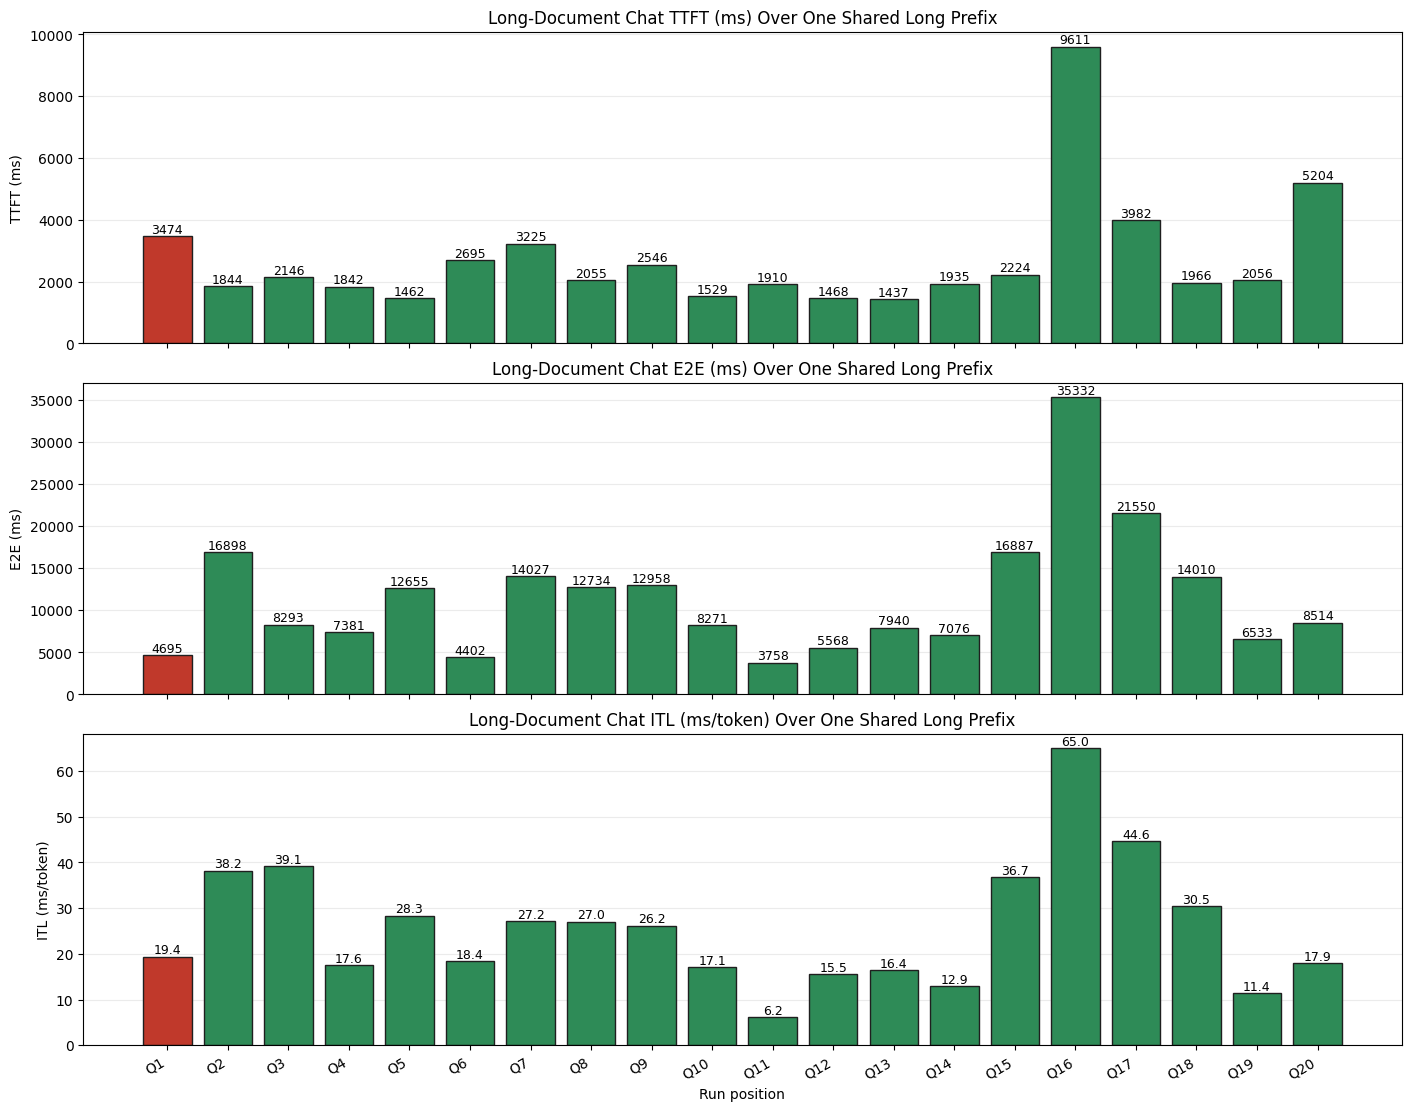

In [8]:
import math

labels = [row['run_label'] for row in records]
colors = ['#c0392b'] + ['#2e8b57'] * (len(records) - 1)

metric_series = {
    'TTFT (ms)': [row['ttft_ms'] for row in records],
    'E2E (ms)': [row['e2e_ms'] for row in records],
    'ITL (ms/token)': [row.get('itl_ms') for row in records],
}

fig, axes = plt.subplots(
    nrows=len(metric_series),
    figsize=(14, 11),
    constrained_layout=True,
    sharex=True,
)

# Normalize to a flat list of Axes.
if isinstance(axes, (list, tuple)):
    axes = list(axes)
elif hasattr(axes, 'ravel'):
    axes = list(axes.ravel())
else:
    axes = [axes]

for ax, (metric_label, raw_values) in zip(axes, metric_series.items()):
    values = [
        float('nan') if (value is None) else float(value)
        for value in raw_values
    ]
    plot_values = [0.0 if math.isnan(value) else value for value in values]
    bars = ax.bar(labels, plot_values, color=colors, edgecolor='#1f1f1f')
    ax.set_title(
        f'Long-Document Chat {metric_label} Over One Shared Long Prefix')
    ax.set_ylabel(metric_label)
    ax.grid(axis='y', alpha=0.25)
    ax.set_axisbelow(True)

    for bar, value in zip(bars, values):
        show_decimal = ('ITL' in metric_label)
        text = 'n/a' if math.isnan(value) else (
            f'{value:.1f}' if show_decimal else f'{value:.0f}')
        y = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            y,
            text,
            ha='center',
            va='bottom',
            fontsize=9,
        )

axes[-1].set_xlabel('Run position')
plt.setp(axes[-1].get_xticklabels(), rotation=30, ha='right')
plt.show()